In [2]:
from scMM.file import MetaboData
import pandas as pd
import numpy as np

df = pd.read_csv("/home/zby/scMM/data/ethology_new/comp_measurements_mut_1.csv")
sample_mask = df.columns.to_series().str.match(r"^(WT|daf-2|elo-1)-\d+$")
IS_MASK = df["IS"].values == "x"
IS_inten = df.loc[IS_MASK, :]
df = df.loc[IS_MASK == False, :]
high_mean = df["Highest Mean"].values
low_mean = df["Lowest Mean"].values
data = MetaboData(
    X = df.loc[:, sample_mask].values.T,
    obs = pd.DataFrame({
        "name": df.columns[sample_mask].values
    }),
    var = pd.DataFrame({
        "mz": df["m/z"].values,
        "rt": df["Retention time (min)"].values,
        "isotope": df["Isotope Distribution"].values,
        "identification": df["Accepted Description"].values
    }),
    is_inten = IS_inten.loc[:, sample_mask].T,
    #process_X = lambda x: np.log1p(x) #- np.log1p(x).mean(axis=0)
)
is_mz_obs = IS_inten["m/z"].values

/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
from matplotlib import font_manager
import matplotlib.pyplot as plt

fname = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"

font_manager.fontManager.addfont(fname)

prop = font_manager.FontProperties(fname=fname)
family_name = prop.get_name()

plt.rcParams["font.family"] = family_name

In [4]:
import logging
logging.basicConfig(level=logging.INFO)

print(data.obs["name"].values)
data.obs["label"] = data.obs["name"].str.extract(r"^(WT|daf-2|elo-1)-\d+$")[0]
data.var["class"] = data.var["identification"].str.extract(r"^([A-Za-z]+)")[0]
print(data.obs["label"].values, data.var["class"].values)

['WT-1' 'WT-2' 'WT-3' 'WT-4' 'WT-5' 'WT-6' 'daf-2-1' 'daf-2-2' 'daf-2-3'
 'daf-2-4' 'daf-2-5' 'daf-2-6' 'elo-1-1' 'elo-1-2' 'elo-1-3' 'elo-1-4'
 'elo-1-5' 'elo-1-6']
['WT' 'WT' 'WT' 'WT' 'WT' 'WT' 'daf-2' 'daf-2' 'daf-2' 'daf-2' 'daf-2'
 'daf-2' 'elo-1' 'elo-1' 'elo-1' 'elo-1' 'elo-1' 'elo-1'] ['Cer' 'DG' 'Cer' 'DG' 'Cer' 'DG' 'Cer' 'DG' 'DG' 'DG' 'DG' 'DG' 'Cer'
 'DG' 'DG' 'DG' 'DG' 'Cer' 'DG' 'DG' 'DG' 'DG' 'Cer' 'DG' 'DG' 'Cer' 'DG'
 'DG' 'DG' 'DG' 'Cer' 'Cer' 'Cer' 'Cer' 'DG' 'Cer' 'Cer' 'TG' 'DG' 'PE'
 'PE' 'TG' 'TG' 'PE' 'GlcCer' 'PE' 'PC' 'SM' 'PC' 'PE' 'PE' 'TG' 'PE' 'DG'
 'PE' 'GlcCer' 'PE' 'PC' 'PC' 'PC' 'PE' 'PE' 'TG' 'TG' 'PC' 'PE' 'PE' 'PC'
 'PE' 'GlcCer' 'PE' 'PC' 'PE' 'PC' 'PE' 'PE' 'TG' 'PE' 'TG' 'PE' 'TG' 'PE'
 'PC' 'PE' 'PC' 'PC' 'PE' 'PE' 'PE' 'PC' 'TG' 'PE' 'PC' 'PE' 'TG' 'PE'
 'PC' 'PE' 'TG' 'PC' 'PE' 'PE' 'PC' 'PE' 'PC' 'TG' 'PC' 'TG' 'PE' 'TG'
 'PE' 'TG' 'PE' 'PC' 'TG' 'PC' 'PE' 'TG' 'PE' 'PC' 'PC' 'PE' 'TG' 'SM'
 'PC' 'PC' 'TG' 'PC' 'TG' 'PC' 'TG' 'PC' 'TG' 'PC'

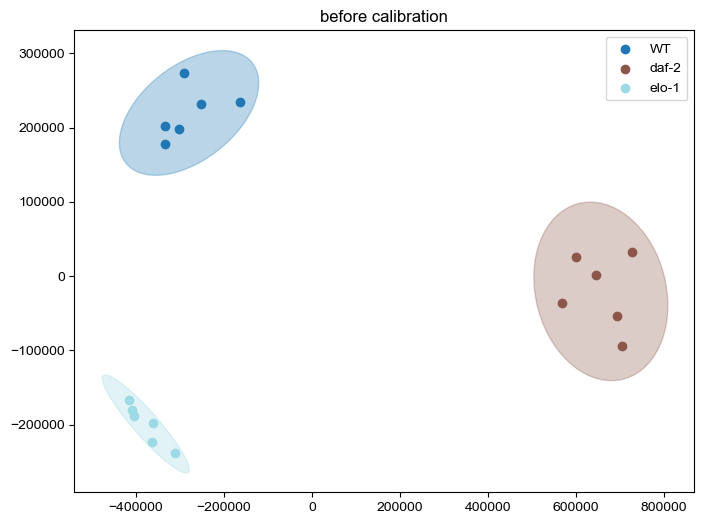

In [5]:
data.plot_pca(color_key = "label", draw_confidence_ellipse=True, save_path = "/home/zby/scMM/data/ethology_new/pca_mut_uncalib.svg", title = "before calibration")

/home/zby/src/scMM/file/_anndata.py:225: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(log2_fc[i], neg_log10_p[i], self.var[name_key][i], fontsize=10, color='black')
/home/zby/src/scMM/file/_anndata.py:227: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  logging.info(f"Plot text of feature {self.var[name_key][i]} at ({log2_fc[i]:.2f}, {neg_log10_p[i]:.2f})")
INFO:root:Plot text of feature TG 52:3 at (2.51, 11.45)
INFO:root:Plot text of feature TG 52:4 at (2.04, 8.70)
INFO:root:Plot text of feature TG 50:2 at (1.70, 8.64)
INFO:root:Plot text of feature TG 53:3 at (2.99, 8.41)
INFO:root:Plot text of feature TG 5

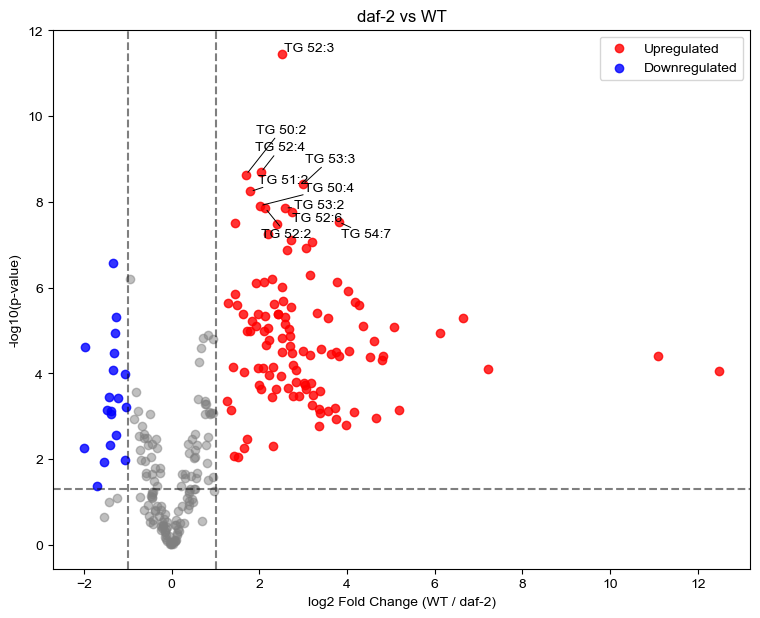

In [6]:
data.volcano_plot(label_key="label", labelx="daf-2", labely="WT", title="daf-2 vs WT", name_key = "identification", save_path="/home/zby/scMM/data/ethology_new/volcano_daf2_vs_WT.svg")

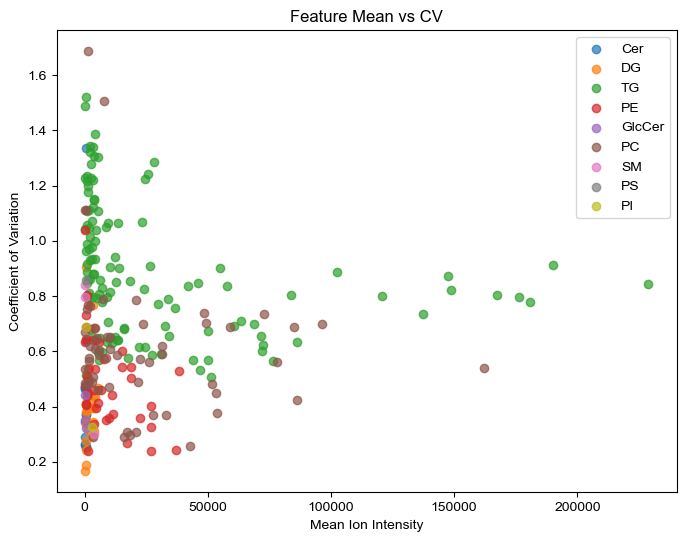

In [7]:
data.plot_features(color_key="class", title="Feature Mean vs CV", save_path="/home/zby/scMM/data/ethology_new/feature_mean_cv_uncalib.svg")

INFO:root:Using 14 out of 36 IS for calibration (CV < 0.35)


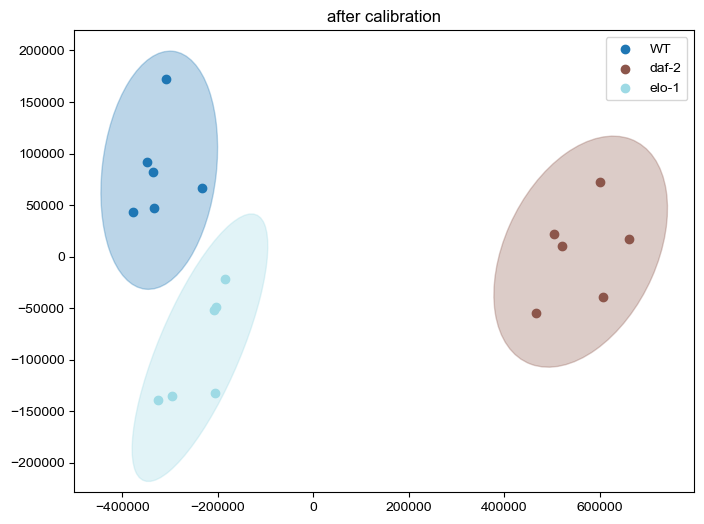

In [8]:
data.gmis_calibration(n_pc = 3, shrinkage = 0.7, is_cv_threshold=0.35)
#data.is_pqn_normalization()
data.plot_pca(color_key = "label", draw_confidence_ellipse=True, save_path = "/home/zby/scMM/data/ethology_new/pca_mut_calib.svg", title = "after calibration")

/home/zby/src/scMM/file/_anndata.py:225: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(log2_fc[i], neg_log10_p[i], self.var[name_key][i], fontsize=10, color='black')
/home/zby/src/scMM/file/_anndata.py:227: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  logging.info(f"Plot text of feature {self.var[name_key][i]} at ({log2_fc[i]:.2f}, {neg_log10_p[i]:.2f})")
INFO:root:Plot text of feature TG 52:3 at (2.56, 11.08)
INFO:root:Plot text of feature TG 53:3 at (3.02, 9.14)
INFO:root:Plot text of feature TG 52:4 at (2.03, 8.81)
INFO:root:Plot text of feature TG 48:2 at (1.78, 8.28)
INFO:root:Plot text of feature TG 5

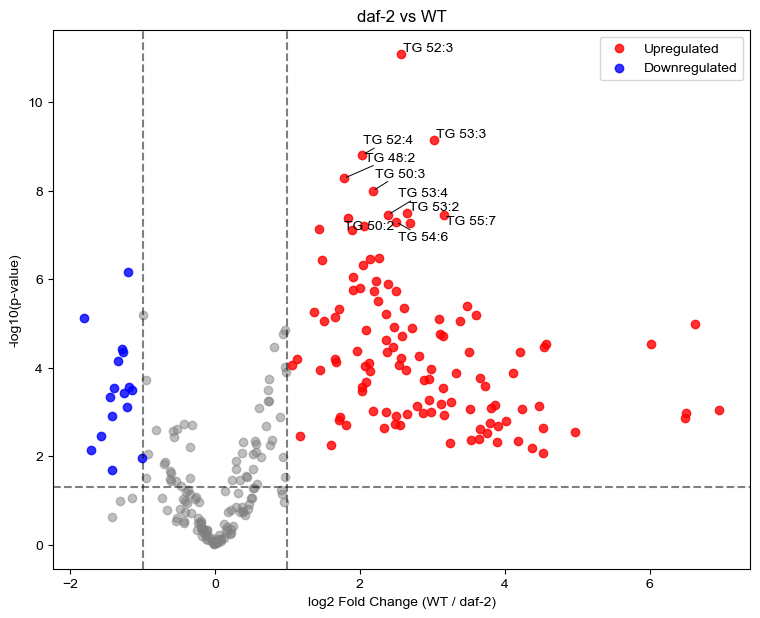

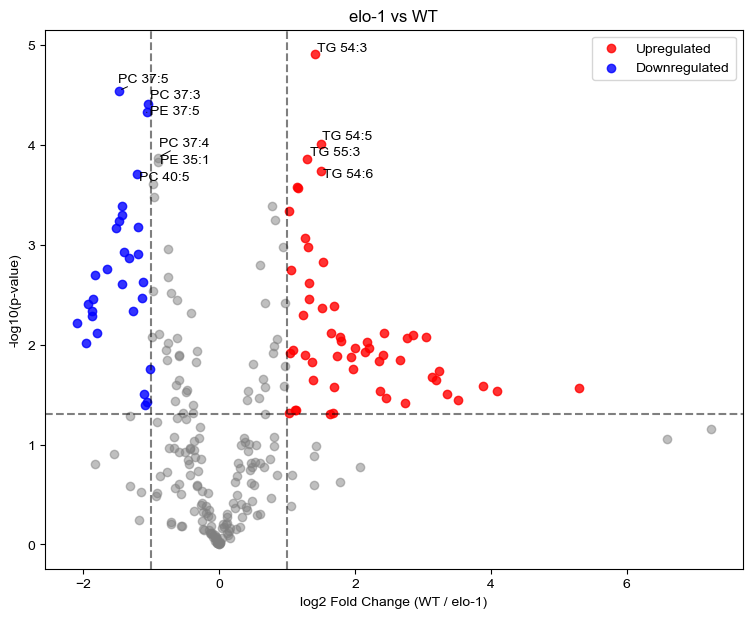

In [9]:
data.volcano_plot(label_key="label", labelx="daf-2", labely="WT", title="daf-2 vs WT", name_key = "identification", save_path="/home/zby/scMM/data/ethology_new/volcano_daf2_vs_WT.svg")
data.volcano_plot(label_key="label", labelx="elo-1", labely="WT", title="elo-1 vs WT", name_key = "identification", save_path="/home/zby/scMM/data/ethology_new/volcano_elo1_vs_WT.svg")

In [10]:
data._t_stats(label_key="label", labelx="daf-2", labely="WT", name_key = "identification", save_csv="/home/zby/scMM/data/ethology_new/t_stats_daf2_vs_WT.csv")
data._t_stats(label_key="label", labelx="elo-1", labely="WT", name_key = "identification", save_csv="/home/zby/scMM/data/ethology_new/t_stats_elo1_vs_WT.csv")

(array([-1.10776756e+00, -1.74349151e+00, -9.45474087e-02,  6.37460485e-03,
         1.55541545e+00, -1.86242131e+00,  1.58220493e+00, -2.72687419e-01,
        -9.15976458e-02, -3.06150522e-01, -2.97515954e-01, -1.54116828e+00,
         1.63448598e+00, -3.07279709e-01, -7.52188108e-02,  6.57276612e-02,
         1.83158440e-01, -1.23476602e+00,  2.99062335e-01, -2.07965612e-01,
        -1.47099322e+00,  3.10758310e-02, -2.27005479e+00, -8.80306206e-01,
         1.21136102e+00, -1.26614735e+00,  8.96551001e-01,  8.23917909e-01,
        -1.77539521e-01, -1.41287918e+00,  1.34473032e+00, -2.33863960e+00,
        -4.83719496e-02,  2.54397504e+00,  7.02692524e-01, -1.08861560e+00,
         1.74801439e+00,  2.52443516e+00,  1.58974644e+00, -1.74689668e+00,
        -4.14439421e+00,  3.02344223e+00, -1.72457086e+00, -2.86791280e+00,
        -6.65759155e-01, -4.12317789e+00, -2.57857992e+00, -5.34570388e+00,
        -3.72816965e+00, -5.54408264e+00,  4.65196701e+00,  4.08265180e+00,
         6.6

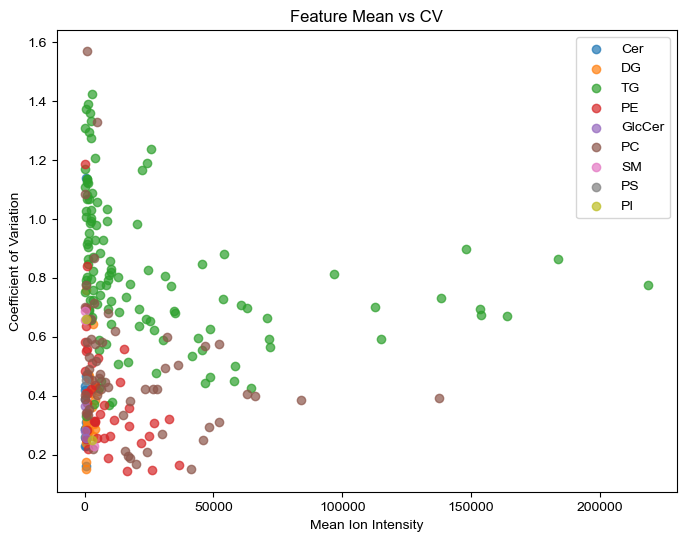

In [11]:
data.plot_features(color_key="class", title="Feature Mean vs CV", save_path="/home/zby/scMM/data/ethology_new/feature_mean_cv_calib.svg")

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/sklearn/covariance/_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 500 iteration: dual gap: -1.718e-01
  warnings.warn(


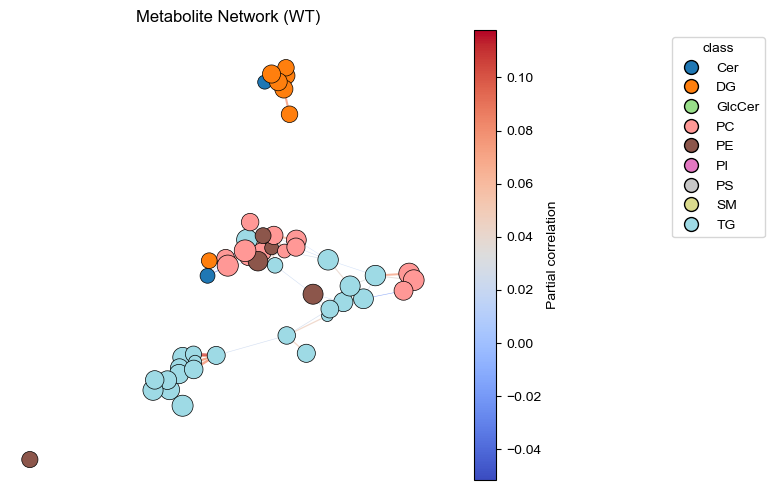

In [12]:
_, centrality, _ = data.metabolite_network_plot(target_label="WT", 
                             label_key="label", 
                             metabolite_name_key="identification", 
                             metabolite_label_key="class", 
                             save_path="/home/zby/scMM/data/ethology_new/metabolite_network_WT.svg", 
                             title="Metabolite Network (WT)", 
                             alpha = 0.7, 
                             edge_threshold = 0.01, 
                             top_nodes = 50,
                             figsize = (8, 5),
                             legend_bbox_to_anchor=(1.5, 1), 
                             edge_width_multiplier=20)

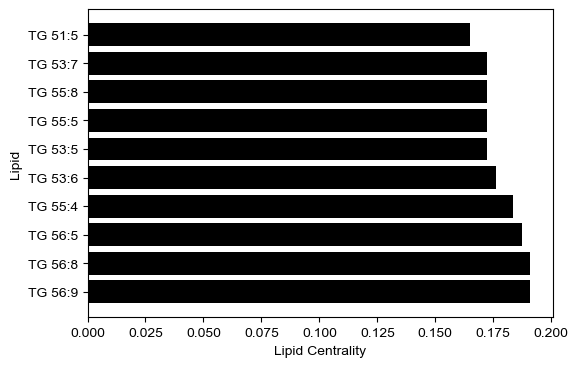

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
lipid_names = list(centrality["degree"].keys())
lipid_centrality = list(centrality["degree"].values())
top_centrality_idx = np.argsort(np.array(lipid_centrality))[::-1][:10]
plt.barh(np.array(lipid_names)[top_centrality_idx], np.array(lipid_centrality)[top_centrality_idx], color = "black")
plt.xlabel("Lipid Centrality")
plt.ylabel("Lipid")
plt.savefig("/home/zby/scMM/data/ethology_new/lipid_centrality_WT.svg", bbox_inches="tight")

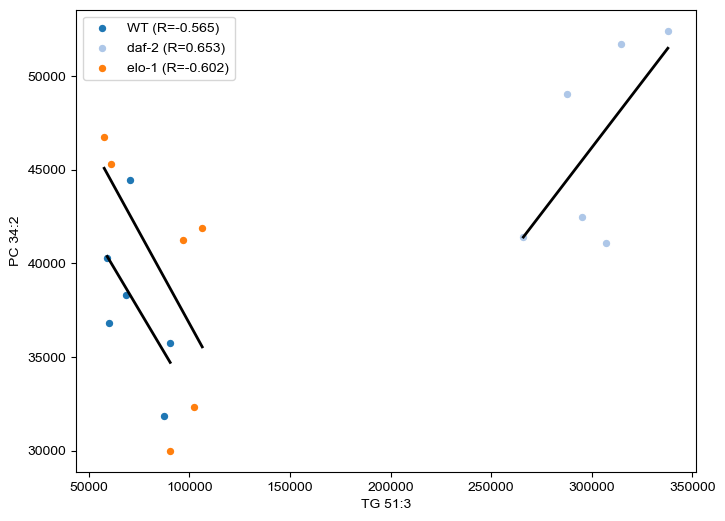

In [14]:
data.feature_scatter(key = "identification", feature_x_name="TG 51:3", feature_y_name="PC 34:2", color_key = "label", lw = 0.5, save_path="/home/zby/scMM/data/ethology_new/feature_scatter_PC38_6_PC40_10.svg")

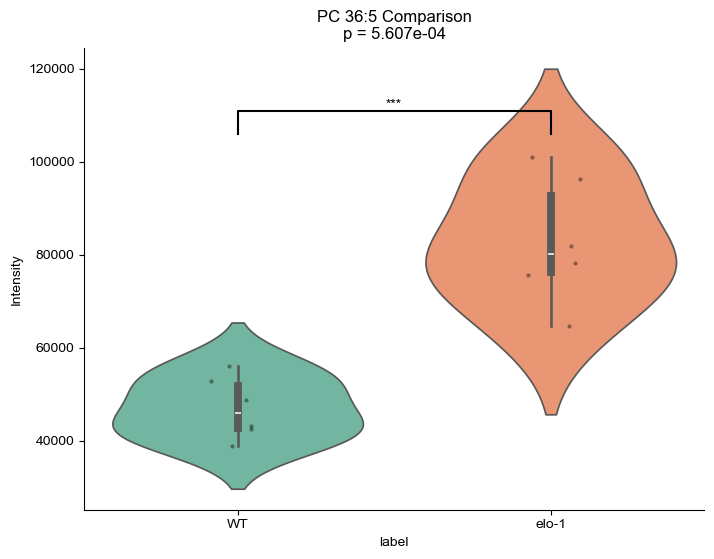

In [18]:
data.feature_compare(feature_key="identification", feature_name="PC 36:2", group_list=["WT", "elo-1"], name_key="label", plot_type="violin", test_method="t", show_points=True, title="PC 36:5 Comparison", save_path="/home/zby/scMM/data/ethology_new/feature_compare_PC36_2.svg")